In [ ]:
!apt-get install openjdk-17-jdk-headless -qq > /dev/null
!pip install -q pyspark openpyxl

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd

In [ ]:
spark = (
    SparkSession.builder
    .appName("Online Retail Analysis")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
excel_path = "/content/drive/MyDrive/bigdata/online_retail_II.xlsx"

In [ ]:
temp_df = pd.read_excel(
    excel_path,
    sheet_name="Year 2009-2010"
)

csv_path = "/content/online_retail_2009_2010.csv"

temp_df.to_csv(csv_path, index=False)

In [ ]:
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(csv_path)
)
df.show(10)

+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 489434|    85048|15CM CHRISTMAS GL...|      12|2009-12-01 07:45:00| 6.95|    13085.0|United Kingdom|
| 489434|   79323P|  PINK CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|   79323W| WHITE CHERRY LIGHTS|      12|2009-12-01 07:45:00| 6.75|    13085.0|United Kingdom|
| 489434|    22041|"RECORD FRAME 7""...|      48|2009-12-01 07:45:00|  2.1|    13085.0|United Kingdom|
| 489434|    21232|STRAWBERRY CERAMI...|      24|2009-12-01 07:45:00| 1.25|    13085.0|United Kingdom|
| 489434|    22064|PINK DOUGHNUT TRI...|      24|2009-12-01 07:45:00| 1.65|    13085.0|United Kingdom|
| 489434|    21871| SAVE THE PLANET MUG|      24|2009-12-01 07:45:00| 1.2

In [ ]:
df.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: double (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
df.describe().show()

+-------+------------------+------------------+--------------------+------------------+------------------+------------------+-----------+
|summary|           Invoice|         StockCode|         Description|          Quantity|             Price|       Customer ID|    Country|
+-------+------------------+------------------+--------------------+------------------+------------------+------------------+-----------+
|  count|            525461|            525461|              522533|            525461|            525461|            417534|     525461|
|   mean| 514496.9241788484| 30518.37992495103|  22226.666666666668|10.337667305470815| 4.688834478671888|15360.645477973052|       NULL|
| stddev|14439.209494469644|20693.168152854723|   646.8974674037095|107.42411026879844|146.12691395292768|1680.8113157457237|       NULL|
|    min|            489434|             10002|  DOORMAT UNION J...|             -9600|         -53594.36|           12346.0|  Australia|
|    max|           C538164|      

In [ ]:
df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+-------+---------+-----------+--------+-----------+-----+-----------+-------+
|Invoice|StockCode|Description|Quantity|InvoiceDate|Price|Customer ID|Country|
+-------+---------+-----------+--------+-----------+-----+-----------+-------+
|      0|        0|       2928|       0|          0|    0|     107927|      0|
+-------+---------+-----------+--------+-----------+-----+-----------+-------+



In [ ]:
total_rows = df.count()
unique_rows = df.dropDuplicates().count()

print("Duplicated rows:", total_rows - unique_rows)

Duplicated rows: 6865


In [ ]:
print("Shape:", (df.count(), len(df.columns)))

Shape: (525461, 8)


In [ ]:
import time

start_time = time.time()

In [ ]:
cleaned_df = df.dropDuplicates()

In [ ]:
print("Rows before removing duplicates:", df.count())
print("Rows after removing duplicates:", cleaned_df.count())
print("Duplicates removed:", df.count() - cleaned_df.count())

Rows before removing duplicates: 525461
Rows after removing duplicates: 518596
Duplicates removed: 6865


In [ ]:
cleaned_df = cleaned_df.withColumn(
    "InvoiceDate",
    F.to_timestamp("InvoiceDate")
)

In [ ]:
cleaned_df = cleaned_df.filter(
    F.col("InvoiceDate").isNotNull()
)

In [ ]:
missing_description = cleaned_df.filter(
    F.col("Description").isNull()
).count()

cleaned_df = cleaned_df.filter(
    F.col("Description").isNotNull()
)

print(
    "Rows with missing Description removed:",
    missing_description
)

Rows with missing Description removed: 2928


In [ ]:
cleaned_df = cleaned_df.withColumn(
    "Description",
    F.trim("Description")
)

cleaned_df = cleaned_df.filter(
    F.col("Description") != ""
)

In [ ]:
missing_customer = cleaned_df.filter(
    F.col("Customer ID").isNull()
).count()

cleaned_df = cleaned_df.filter(
    F.col("Customer ID").isNotNull()
)

print(
    "Rows with missing Customer ID removed:",
    missing_customer
)

cleaned_df = cleaned_df.withColumnRenamed(
    "Customer ID",
    "CustomerID"
)

cleaned_df = cleaned_df.withColumn(
    "CustomerID",
    F.col("CustomerID").cast("int").cast("string")
)

Rows with missing Customer ID removed: 104905


In [ ]:
cleaned_df = (
    cleaned_df
    .withColumn(
        "Quantity",
        F.col("Quantity").cast("int")
    )
    .withColumn(
        "Price",
        F.col("Price").cast("double")
    )
)
cleaned_df = cleaned_df.filter(
    F.col("Quantity").isNotNull() &
    F.col("Price").isNotNull()
)

In [ ]:
cleaned_df = cleaned_df.withColumn(
    "Is_Cancelled",
    F.upper(F.col("Invoice")).startswith("C")
)

print("Number of cancelled transactions:")

print(
    cleaned_df.filter(
        F.col("Is_Cancelled") == True
    ).count()
)

cancelled_df = cleaned_df.filter(
    F.col("Is_Cancelled") == True
)

sales_df = cleaned_df.filter(
    F.col("Is_Cancelled") == False
)

Number of cancelled transactions:
9816


In [ ]:
rows_before = sales_df.count()

sales_df = sales_df.filter(
    (F.col("Quantity") > 0) &
    (F.col("Price") > 0)
)

rows_after = sales_df.count()

print(
    "Invalid completed-sales records removed:",
    rows_before - rows_after
)

Invalid completed-sales records removed: 31


In [ ]:
sales_df = sales_df.withColumn(
    "Revenue",
    F.col("Quantity") * F.col("Price")
)
sales_df.select(
    "Quantity",
    "Price",
    "Revenue"
).show(10)

+--------+-----+------------------+
|Quantity|Price|           Revenue|
+--------+-----+------------------+
|      48| 0.38|18.240000000000002|
|       2| 2.55|               5.1|
|      12| 1.25|              15.0|
|       6|  2.1|12.600000000000001|
|      12| 2.95|35.400000000000006|
|       1| 3.75|              3.75|
|       1| 2.95|              2.95|
|       5| 0.85|              4.25|
|       6| 3.75|              22.5|
|      40| 0.85|              34.0|
+--------+-----+------------------+
only showing top 10 rows


In [ ]:
sales_df = (
    sales_df
    .withColumn("Year", F.year("InvoiceDate"))
    .withColumn("Month", F.month("InvoiceDate"))
    .withColumn(
        "Month_Name",
        F.date_format("InvoiceDate", "MMMM")
    )
    .withColumn(
        "Year_Month",
        F.date_format("InvoiceDate", "yyyy-MM")
    )
    .withColumn("Day", F.dayofmonth("InvoiceDate"))
    .withColumn(
        "Day_Name",
        F.date_format("InvoiceDate", "EEEE")
    )
    .withColumn("Hour", F.hour("InvoiceDate"))
)

In [ ]:
sales_df.count()      # Force Spark to execute all transformations

end_time = time.time()

preprocessing_time = end_time - start_time

print(f"PySpark preprocessing time: {preprocessing_time:.2f} seconds")

PySpark preprocessing time: 32.14 seconds


In [ ]:
print("Cleaned sales dataset shape:")
print((sales_df.count(), len(sales_df.columns)))

Cleaned sales dataset shape:
(400916, 17)


In [ ]:
print("Remaining missing values:")

sales_df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in sales_df.columns
]).show()

Remaining missing values:
+-------+---------+-----------+--------+-----------+-----+----------+-------+------------+-------+----+-----+----------+----------+---+--------+----+
|Invoice|StockCode|Description|Quantity|InvoiceDate|Price|CustomerID|Country|Is_Cancelled|Revenue|Year|Month|Month_Name|Year_Month|Day|Day_Name|Hour|
+-------+---------+-----------+--------+-----------+-----+----------+-------+------------+-------+----+-----+----------+----------+---+--------+----+
|      0|        0|          0|       0|          0|    0|         0|      0|           0|      0|   0|    0|         0|         0|  0|       0|   0|
+-------+---------+-----------+--------+-----------+-----+----------+-------+------------+-------+----+-----+----------+----------+---+--------+----+



In [ ]:
remaining_duplicates = (
    sales_df.count() -
    sales_df.dropDuplicates().count()
)

print("Remaining duplicate rows:", remaining_duplicates)

Remaining duplicate rows: 0


In [ ]:
sales_df.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Is_Cancelled: boolean (nullable = true)
 |-- Revenue: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Month_Name: string (nullable = true)
 |-- Year_Month: string (nullable = true)
 |-- Day: integer (nullable = true)
 |-- Day_Name: string (nullable = true)
 |-- Hour: integer (nullable = true)



In [ ]:
sales_df.select(
    "Quantity",
    "Price",
    "Revenue"
).describe().show()

+-------+------------------+------------------+------------------+
|summary|          Quantity|             Price|           Revenue|
+-------+------------------+------------------+------------------+
|  count|            400916|            400916|            400916|
|   mean|13.767417613664708|3.3058261431308207|21.945329555326122|
| stddev| 97.63838485749395|35.047718955180066| 77.75807455845013|
|    min|                 1|             0.001|             0.001|
|    max|             19152|           10953.5|           15818.4|
+-------+------------------+------------------+------------------+



In [ ]:
sales_df.show(10)

+-------+---------+--------------------+--------+-------------------+-----+----------+--------------+------------+------------------+----+-----+----------+----------+---+--------+----+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|CustomerID|       Country|Is_Cancelled|           Revenue|Year|Month|Month_Name|Year_Month|Day|Day_Name|Hour|
+-------+---------+--------------------+--------+-------------------+-----+----------+--------------+------------+------------------+----+-----+----------+----------+---+--------+----+
| 489445|    35951|FOLKART BAUBLE CH...|      48|2009-12-01 09:57:00| 0.38|     17519|United Kingdom|       false|18.240000000000002|2009|   12|  December|   2009-12|  1| Tuesday|   9|
| 489488|    22301|COFFEE MUG CAT + ...|       2|2009-12-01 10:59:00| 2.55|     17238|United Kingdom|       false|               5.1|2009|   12|  December|   2009-12|  1| Tuesday|  10|
| 489519|    84946|ANTIQUE SILVER TE...|      12|2009-12-01 11:37:00| 1.25|

In [ ]:
sales_df.coalesce(1).write.mode(
    "overwrite"
).option(
    "header", True
).csv(
    "/content/online_retail_cleaned_sales"
)

In [ ]:
cancelled_df.coalesce(1).write.mode(
    "overwrite"
).option(
    "header", True
).csv(
    "/content/online_retail_cancelled_transactions"
)

In [ ]:
overall_summary = sales_df.agg(
    F.count("*").alias("Transaction_Rows"),
    F.countDistinct("Invoice").alias("Total_Orders"),
    F.countDistinct("CustomerID").alias("Total_Customers"),
    F.sum("Quantity").alias("Total_Quantity_Sold"),
    F.round(F.sum("Revenue"), 2).alias("Total_Revenue"),
    F.round(F.avg("Revenue"), 2).alias("Average_Revenue_Per_Row")
)

overall_summary.show()

+----------------+------------+---------------+-------------------+-------------+-----------------------+
|Transaction_Rows|Total_Orders|Total_Customers|Total_Quantity_Sold|Total_Revenue|Average_Revenue_Per_Row|
+----------------+------------+---------------+-------------------+-------------+-----------------------+
|          400916|       19213|           4312|            5519578|   8798233.74|                  21.95|
+----------------+------------+---------------+-------------------+-------------+-----------------------+



In [ ]:

order_summary = (
    sales_df
    .groupBy("Invoice")
    .agg(
        F.sum("Revenue").alias("Order_Revenue")
    )
    .agg(
        F.round(
            F.avg("Order_Revenue"),
            2
        ).alias("Average_Order_Value")
    )
)

order_summary.show()

+-------------------+
|Average_Order_Value|
+-------------------+
|             457.93|
+-------------------+



In [ ]:
country_revenue = (
    sales_df
    .groupBy("Country")
    .agg(
        F.round(
            F.sum("Revenue"),
            2
        ).alias("Total_Revenue"),

        F.countDistinct(
            "Invoice"
        ).alias("Total_Orders"),

        F.sum(
            "Quantity"
        ).alias("Total_Quantity_Sold")
    )
    .orderBy(
        F.desc("Total_Revenue")
    )
)

country_revenue.show(10, truncate=False)

+--------------+-------------+------------+-------------------+
|Country       |Total_Revenue|Total_Orders|Total_Quantity_Sold|
+--------------+-------------+------------+-------------------+
|United Kingdom|7381644.43   |17612       |4430148            |
|EIRE          |356041.86    |316         |181413             |
|Netherlands   |268784.35    |135         |183615             |
|Germany       |202025.39    |347         |108615             |
|France        |146107.07    |236         |162048             |
|Sweden        |53147.99     |68          |52417              |
|Denmark       |50906.85     |26          |229690             |
|Spain         |47568.65     |66          |22841              |
|Switzerland   |43921.39     |40          |22255              |
|Australia     |31446.8      |40          |20189              |
+--------------+-------------+------------+-------------------+
only showing top 10 rows


In [ ]:
international_country_revenue = (
    country_revenue
    .filter(
        F.col("Country") != "United Kingdom"
    )
)

international_country_revenue.show(10, truncate=False)

+---------------+-------------+------------+-------------------+
|Country        |Total_Revenue|Total_Orders|Total_Quantity_Sold|
+---------------+-------------+------------+-------------------+
|EIRE           |356041.86    |316         |181413             |
|Netherlands    |268784.35    |135         |183615             |
|Germany        |202025.39    |347         |108615             |
|France         |146107.07    |236         |162048             |
|Sweden         |53147.99     |68          |52417              |
|Denmark        |50906.85     |26          |229690             |
|Spain          |47568.65     |66          |22841              |
|Switzerland    |43921.39     |40          |22255              |
|Australia      |31446.8      |40          |20189              |
|Channel Islands|24546.32     |30          |11991              |
+---------------+-------------+------------+-------------------+
only showing top 10 rows


In [ ]:
top_products_quantity = (
    sales_df
    .groupBy(
        "StockCode",
        "Description"
    )
    .agg(
        F.sum(
            "Quantity"
        ).alias("Total_Quantity_Sold"),

        F.round(
            F.sum("Revenue"),
            2
        ).alias("Total_Revenue"),

        F.countDistinct(
            "Invoice"
        ).alias("Number_of_Orders")
    )
    .orderBy(
        F.desc("Total_Quantity_Sold")
    )
)

top_products_quantity.show(10, truncate=False)

+---------+----------------------------------+-------------------+-------------+----------------+
|StockCode|Description                       |Total_Quantity_Sold|Total_Revenue|Number_of_Orders|
+---------+----------------------------------+-------------------+-------------+----------------+
|85123A   |WHITE HANGING HEART T-LIGHT HOLDER|56814              |151339.16    |3021            |
|84077    |WORLD WAR 2 GLIDERS ASSTD DESIGNS |54610              |11285.54     |461             |
|17003    |BROCADE RING PURSE                |48166              |8847.66      |188             |
|21212    |PACK OF 72 RETRO SPOT CAKE CASES  |45129              |21838.23     |1160            |
|84879    |ASSORTED COLOUR BIRD ORNAMENT     |44431              |70291.03     |1333            |
|84991    |60 TEATIME FAIRY CAKE CASES       |35656              |17436.3      |1136            |
|21977    |PACK OF 60 PINK PAISLEY CAKE CASES|30871              |15045.1      |928             |
|85099B   |JUMBO BAG

In [ ]:
top_products_revenue = (
    top_products_quantity
    .orderBy(
        F.desc("Total_Revenue")
    )
)

top_products_revenue.show(10, truncate=False)

+---------+-----------------------------------+-------------------+-------------+----------------+
|StockCode|Description                        |Total_Quantity_Sold|Total_Revenue|Number_of_Orders|
+---------+-----------------------------------+-------------------+-------------+----------------+
|85123A   |WHITE HANGING HEART T-LIGHT HOLDER |56814              |151339.16    |3021            |
|22423    |REGENCY CAKESTAND 3 TIER           |12484              |143727.6     |1687            |
|M        |Manual                             |2568               |98531.99     |382             |
|84879    |ASSORTED COLOUR BIRD ORNAMENT      |44431              |70291.03     |1333            |
|85099B   |JUMBO BAG RED RETROSPOT            |29519              |51644.25     |1060            |
|POST     |POSTAGE                            |2212               |48741.08     |738             |
|84347    |ROTATING SILVER ANGELS T-LIGHT HLDR|21579              |40156.05     |244             |
|22086    

In [ ]:
top_customers = (
    sales_df
    .groupBy("CustomerID")
    .agg(
        F.round(
            F.sum("Revenue"),
            2
        ).alias("Total_Spending"),

        F.countDistinct(
            "Invoice"
        ).alias("Total_Orders"),

        F.sum(
            "Quantity"
        ).alias("Total_Quantity_Purchased")
    )
    .withColumn(
        "Average_Order_Value",
        F.round(
            F.col("Total_Spending") /
            F.col("Total_Orders"),
            2
        )
    )
    .orderBy(
        F.desc("Total_Spending")
    )
)

top_customers.show(10, truncate=False)

+----------+--------------+------------+------------------------+-------------------+
|CustomerID|Total_Spending|Total_Orders|Total_Quantity_Purchased|Average_Order_Value|
+----------+--------------+------------+------------------------+-------------------+
|18102     |349164.35     |89          |124216                  |3923.19            |
|14646     |248396.5      |78          |170278                  |3184.57            |
|14156     |196549.74     |102         |108105                  |1926.96            |
|14911     |152121.22     |205         |69709                   |742.05             |
|13694     |131443.19     |94          |125893                  |1398.33            |
|17511     |84541.17      |31          |55107                   |2727.13            |
|15061     |83284.38      |86          |51791                   |968.42             |
|16684     |80489.21      |27          |54555                   |2981.08            |
|16754     |65500.07      |29          |63551         

In [ ]:
# How does monthly revenue change; to calculate monthly sales performance
monthly_revenue = (
    sales_df
    .groupBy("Year_Month")
    .agg(
        F.round(
            F.sum("Revenue"),
            2
        ).alias("Monthly_Revenue"),

        F.countDistinct(
            "Invoice"
        ).alias("Total_Orders"),

        F.sum(
            "Quantity"
        ).alias("Total_Quantity_Sold"),

        F.countDistinct(
            "CustomerID"
        ).alias("Active_Customers")
    )
    .orderBy("Year_Month")
)

monthly_revenue.show(20, truncate=False)

+----------+---------------+------------+-------------------+----------------+
|Year_Month|Monthly_Revenue|Total_Orders|Total_Quantity_Sold|Active_Customers|
+----------+---------------+------------+-------------------+----------------+
|2009-12   |683504.01      |1512        |398660             |955             |
|2010-01   |555802.67      |1011        |370082             |720             |
|2010-02   |504558.96      |1104        |371861             |772             |
|2010-03   |696978.47      |1524        |502100             |1057            |
|2010-04   |591982.0       |1329        |350587             |942             |
|2010-05   |597833.38      |1377        |384960             |966             |
|2010-06   |636371.13      |1497        |389872             |1041            |
|2010-07   |589736.17      |1381        |324632             |928             |
|2010-08   |602224.6       |1293        |452542             |911             |
|2010-09   |829013.95      |1689        |567153     

In [ ]:
#To identify the highest-revenue month
monthly_revenue.orderBy(
    F.desc("Monthly_Revenue")
).show(5, truncate=False)

+----------+---------------+------------+-------------------+----------------+
|Year_Month|Monthly_Revenue|Total_Orders|Total_Quantity_Sold|Active_Customers|
+----------+---------------+------------+-------------------+----------------+
|2010-11   |1166460.02     |2587        |653068             |1607            |
|2010-10   |1033112.01     |2133        |596432             |1497            |
|2010-09   |829013.95      |1689        |567153             |1145            |
|2010-03   |696978.47      |1524        |502100             |1057            |
|2009-12   |683504.01      |1512        |398660             |955             |
+----------+---------------+------------+-------------------+----------------+
only showing top 5 rows


In [ ]:
#How many cancelled transactions exist
cancelled_summary = cancelled_df.agg(
    F.count("*").alias("Cancelled_Transaction_Rows"),
    F.countDistinct("Invoice").alias("Cancelled_Invoices"),
    F.countDistinct("CustomerID").alias("Customers_With_Cancellations"),
    F.sum(
        F.abs(F.col("Quantity"))
    ).alias("Cancelled_Quantity"),

    F.round(
        F.sum(
            F.abs(
                F.col("Quantity") * F.col("Price")
            )
        ),
        2
    ).alias("Estimated_Cancelled_Value")
)

cancelled_summary.show()

+--------------------------+------------------+----------------------------+------------------+-------------------------+
|Cancelled_Transaction_Rows|Cancelled_Invoices|Customers_With_Cancellations|Cancelled_Quantity|Estimated_Cancelled_Value|
+--------------------------+------------------+----------------------------+------------------+-------------------------+
|                      9816|              4372|                        1798|            211856|                483378.16|
+--------------------------+------------------+----------------------------+------------------+-------------------------+



In [ ]:
# Calculate the invoice cancellation rate:
completed_invoices = (
    sales_df
    .select("Invoice")
    .distinct()
    .count()
)

cancelled_invoices = (
    cancelled_df
    .select("Invoice")
    .distinct()
    .count()
)

total_invoices = completed_invoices + cancelled_invoices

cancellation_rate = (
    cancelled_invoices /
    total_invoices
) * 100

print("Completed invoices:", completed_invoices)
print("Cancelled invoices:", cancelled_invoices)
print(f"Cancellation rate: {cancellation_rate:.2f}%")

Completed invoices: 19213
Cancelled invoices: 4372
Cancellation rate: 18.54%


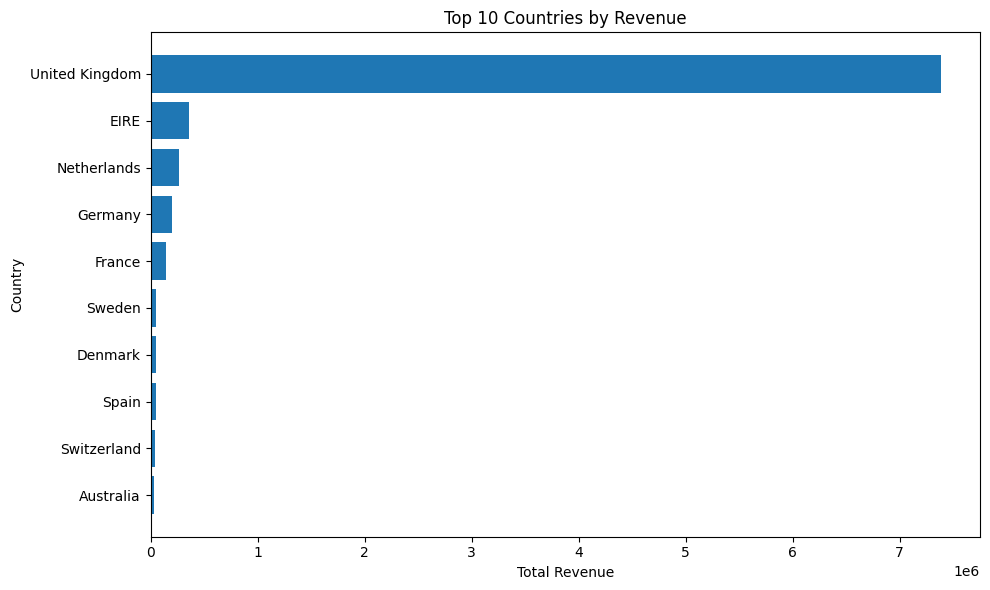

In [ ]:
import matplotlib.pyplot as plt

country_plot = (
    country_revenue
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(10, 6))

plt.barh(
    country_plot["Country"],
    country_plot["Total_Revenue"]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

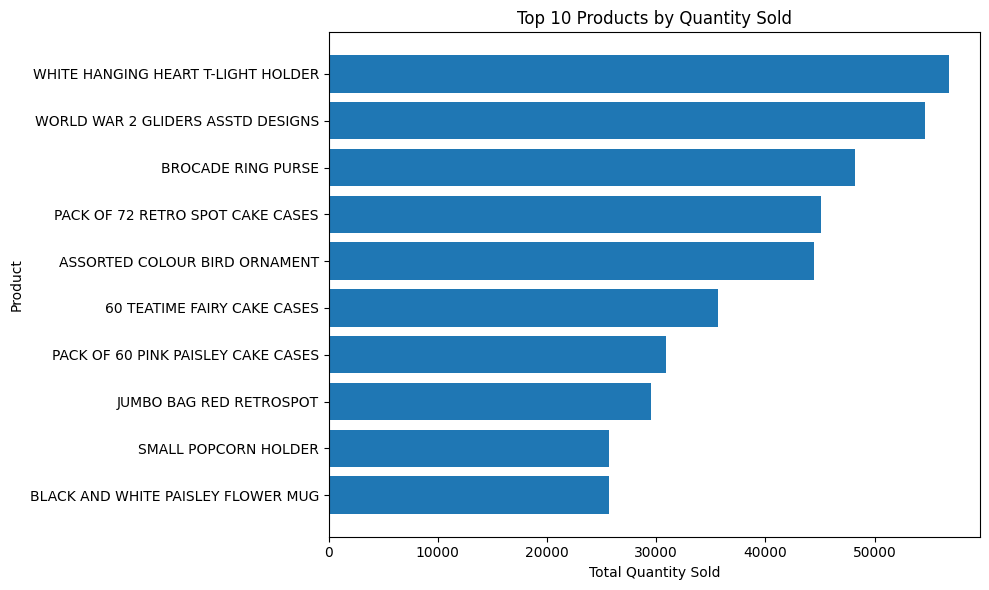

In [ ]:
product_plot = (
    top_products_quantity
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(10, 6))

plt.barh(
    product_plot["Description"],
    product_plot["Total_Quantity_Sold"]
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

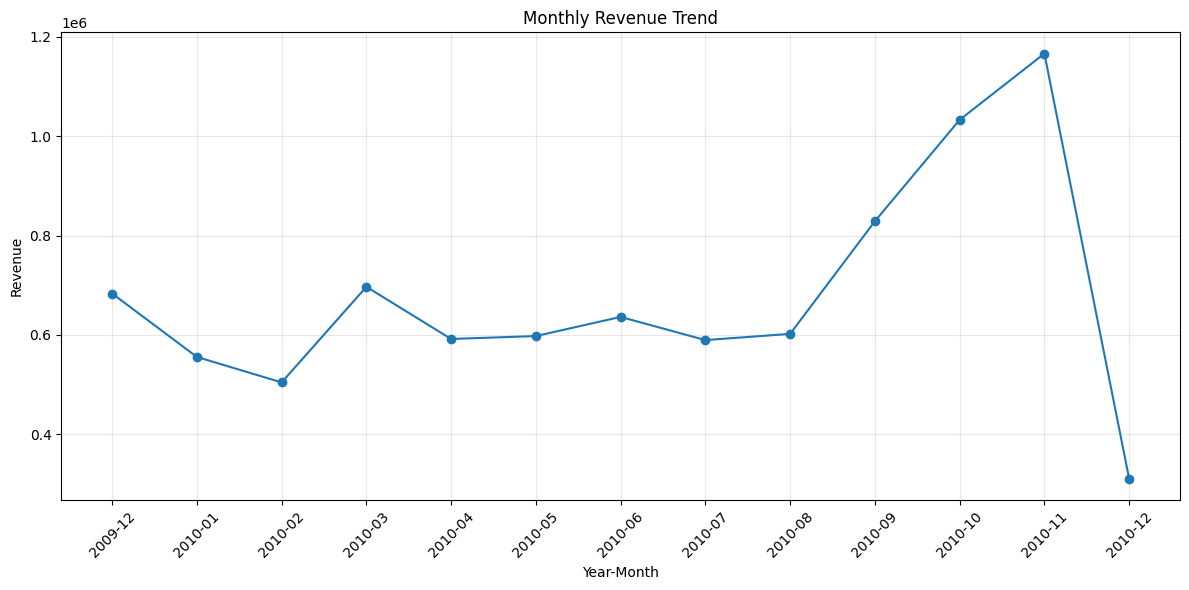

In [ ]:
import matplotlib.pyplot as plt

monthly_plot = monthly_revenue.toPandas()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_plot["Year_Month"],
    monthly_plot["Monthly_Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

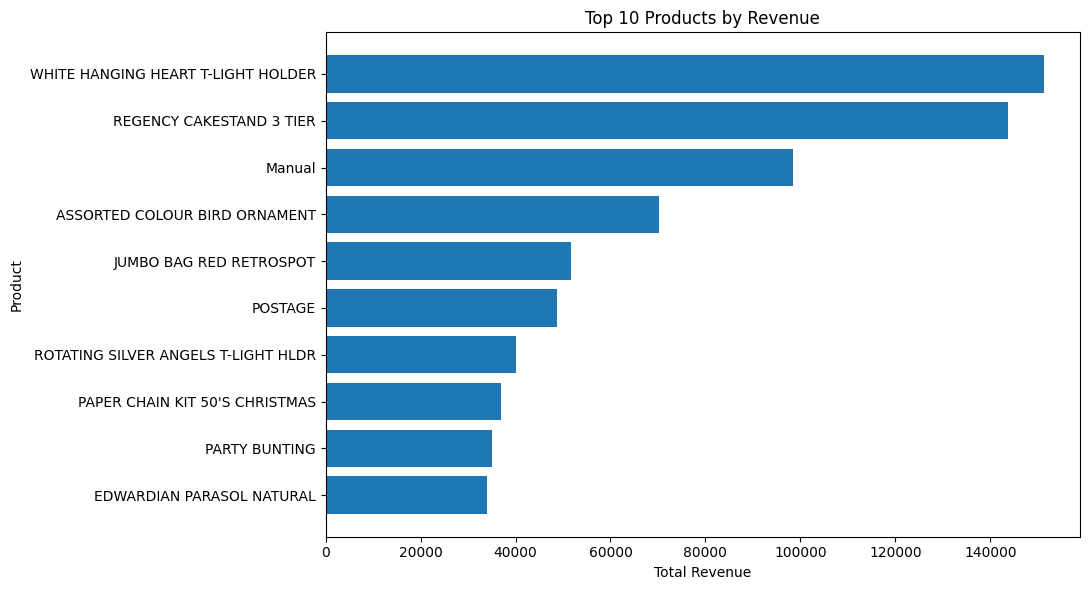

In [ ]:
product_revenue_plot = (
    top_products_revenue
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(11, 6))

plt.barh(
    product_revenue_plot["Description"],
    product_revenue_plot["Total_Revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

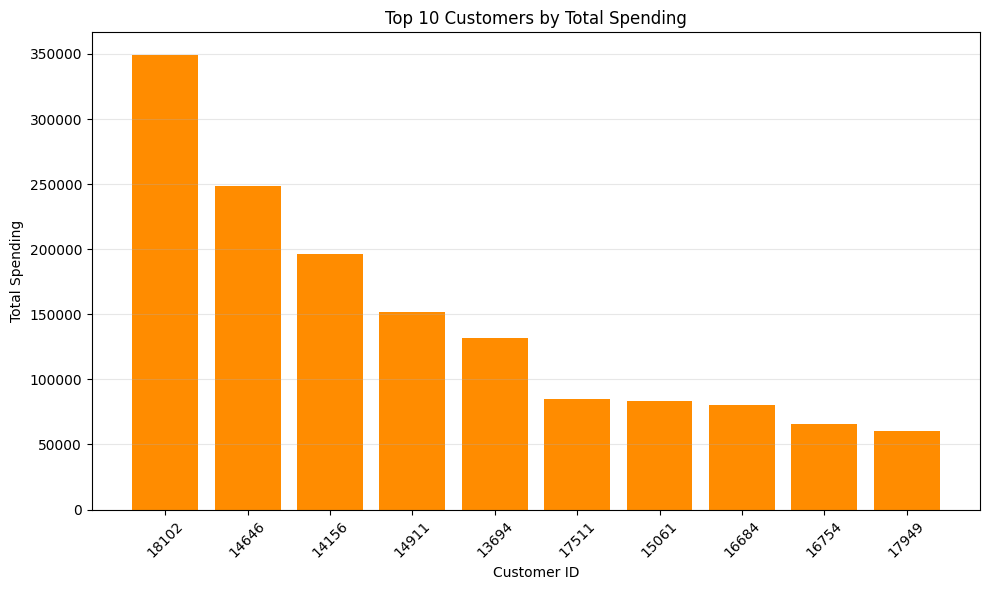

In [ ]:
customer_plot = (
    top_customers
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(10, 6))

plt.bar(
    customer_plot["CustomerID"].astype(str),
    customer_plot["Total_Spending"],
    color="darkorange"
)

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

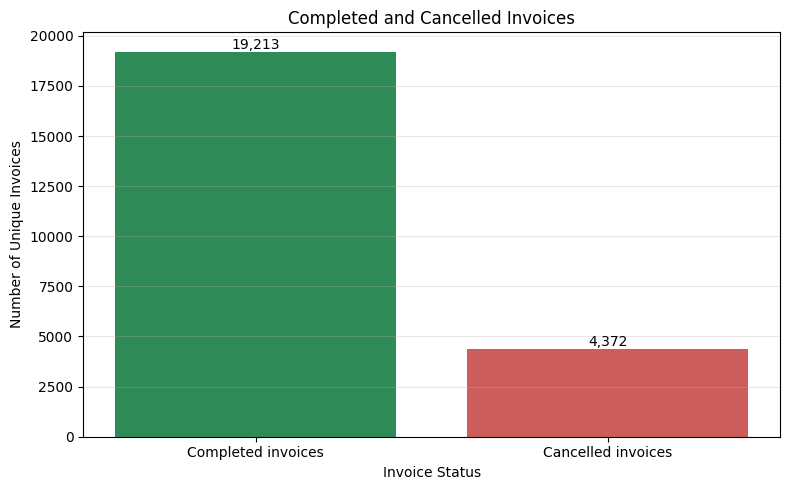

In [ ]:
transaction_status = [
    "Completed invoices",
    "Cancelled invoices"
]

transaction_counts = [
    completed_invoices,
    cancelled_invoices
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    transaction_status,
    transaction_counts,
    color=["seagreen", "indianred"]
)

plt.title("Completed and Cancelled Invoices")
plt.xlabel("Invoice Status")
plt.ylabel("Number of Unique Invoices")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil

folder = "/content/online_retail_cleaned_sales"

csv_file = [
    f for f in os.listdir(folder)
    if f.endswith(".csv")
][0]

shutil.copy(
    os.path.join(folder, csv_file),
    "/content/online_retail_cleaned_sales.csv"
)

'/content/online_retail_cleaned_sales.csv'

In [ ]:
from google.colab import files

files.download("/content/online_retail_cleaned_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
folder = "/content/online_retail_cancelled_transactions"

csv_file = [
    f for f in os.listdir(folder)
    if f.endswith(".csv")
][0]

shutil.copy(
    os.path.join(folder, csv_file),
    "/content/online_retail_cancelled_transactions.csv"
)

files.download("/content/online_retail_cancelled_transactions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>